#📌 Extracción

In [23]:
import pandas as pd
import requests

# URL del dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Solicitud a la API
response = requests.get(url)

# Convertir a JSON
data = response.json()

# Convertir a DataFrame
df = pd.json_normalize(data)

# Visualizar primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [24]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

#🔧 Transformación

In [25]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [28]:
df = df.dropna()

In [29]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

In [30]:
df.replace({"Yes":1, "No":0}, inplace=True)

/tmp/ipykernel_1870/3520732665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Yes":1, "No":0}, inplace=True)


In [31]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   int64  
 5   customer.Dependents        7256 non-null   int64  
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   int64  
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

Estadistica

In [32]:
df.describe()

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158514
std,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004191
min,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.181667
50%,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,2.996667
max,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


Distribución de churn

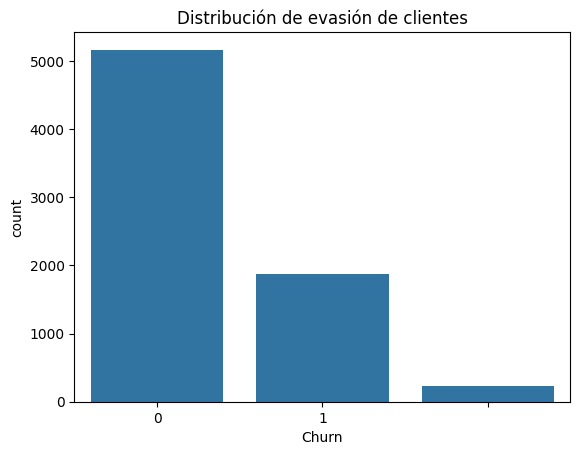

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Distribución de evasión de clientes")
plt.show()

Churn por variables categóricas

Género

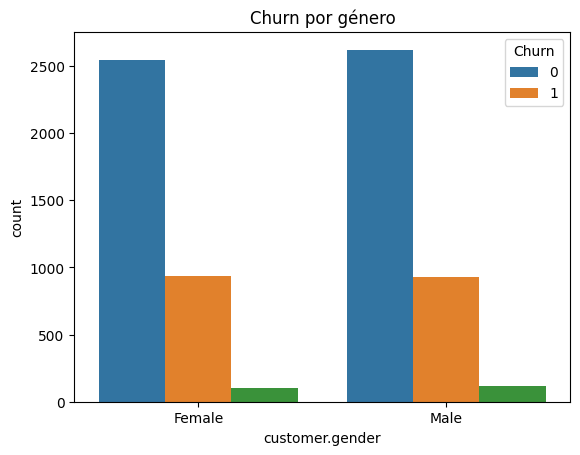

In [34]:
sns.countplot(x="customer.gender", hue="Churn", data=df)

plt.title("Churn por género")
plt.show()

Tipo de contrato

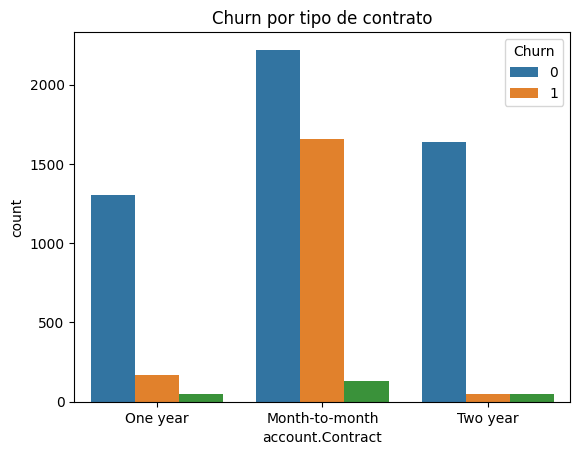

In [35]:
sns.countplot(x="account.Contract", hue="Churn", data=df)

plt.title("Churn por tipo de contrato")
plt.show()

Método de pago

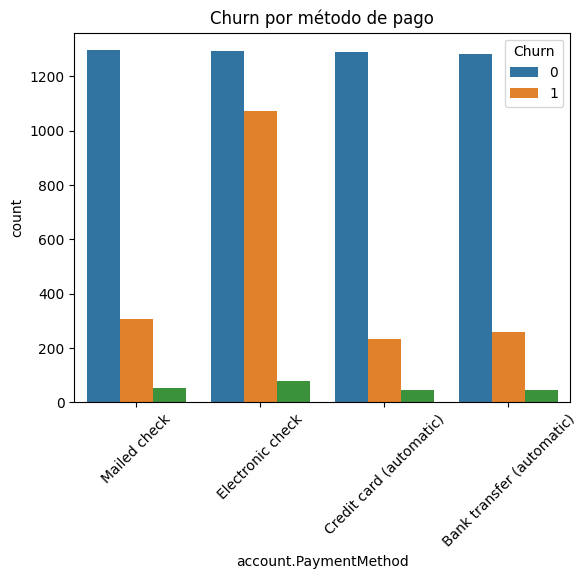

In [36]:
sns.countplot(x="account.PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)
plt.title("Churn por método de pago")
plt.show()

Variables numéricas

Gasto mensual

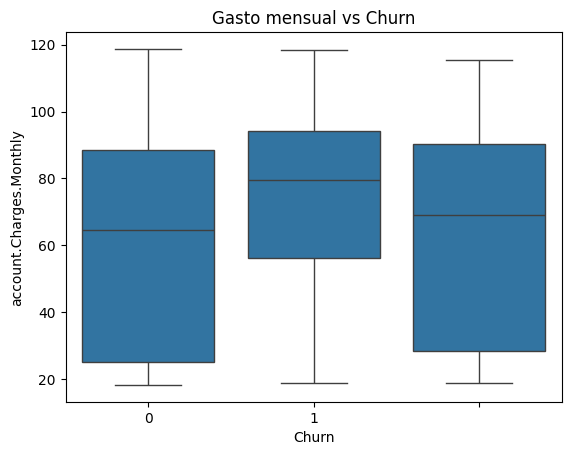

In [37]:
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)

plt.title("Gasto mensual vs Churn")
plt.show()

Antigüedad del cliente

In [40]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

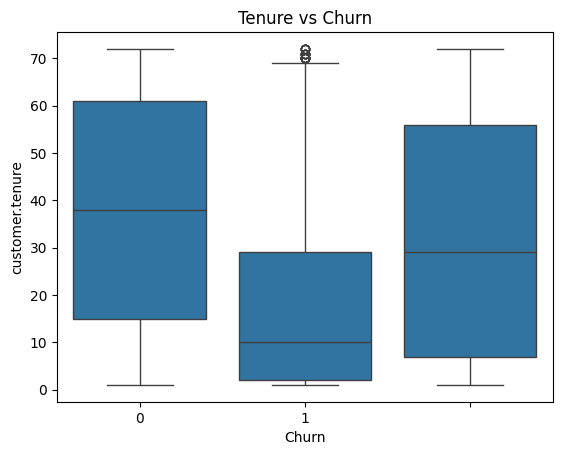

In [42]:
sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

#📄Informe final



## Introducción

El objetivo de este proyecto es analizar los factores que influyen en la evasión de clientes (*Churn*) en la empresa **Telecom X**. Actualmente, la compañía enfrenta una alta tasa de cancelación de servicios por parte de sus clientes, lo cual representa una pérdida significativa de ingresos y estabilidad en su base de usuarios.

A través de este análisis exploratorio de datos (EDA), se busca identificar patrones y variables que puedan estar relacionadas con la cancelación del servicio. Estos hallazgos permitirán proporcionar información valiosa que apoye al equipo de **Data Science** en el desarrollo de modelos predictivos y estrategias para mejorar la retención de clientes.

---

## Limpieza y tratamiento de datos

Durante el proceso de preparación de los datos se realizaron varias etapas fundamentales para garantizar la calidad y consistencia del dataset:

- Importación de los datos desde una API en formato **JSON**.
- Conversión de los datos a un **DataFrame de Pandas** para facilitar su manipulación y análisis.
- Exploración de la estructura del dataset, revisando tipos de datos y columnas disponibles.
- Identificación de **valores nulos, duplicados e inconsistencias** en los datos.
- Conversión de variables que estaban en formato texto a **variables numéricas** cuando fue necesario.
- Eliminación de registros con valores faltantes que podían afectar el análisis.
- Creación de una nueva variable llamada **Cuentas_Diarias**, calculada a partir de la facturación mensual, para obtener una visión más detallada del gasto diario de los clientes.
- Estandarización de algunas variables categóricas para facilitar el análisis.

Estas acciones permitieron preparar un conjunto de datos limpio y consistente para la etapa de análisis exploratorio.

---

## Análisis Exploratorio de Datos

Durante el análisis exploratorio se realizaron diferentes visualizaciones y análisis estadísticos para comprender mejor el comportamiento de los clientes.

Los análisis realizados incluyeron:

- **Distribución de la variable Churn**, para observar la proporción de clientes que permanecen en la empresa frente a aquellos que cancelan el servicio.
- **Análisis de evasión por variables categóricas**, como género, tipo de contrato y método de pago.
- **Análisis de evasión por variables numéricas**, como el gasto mensual y el tiempo que el cliente ha permanecido con la empresa.
- Exploración de posibles relaciones entre diferentes variables que podrían influir en la cancelación del servicio.

A través de estas visualizaciones se pudieron identificar algunos patrones importantes en el comportamiento de los clientes.

---

## Conclusiones e Insights

A partir del análisis realizado, se identificaron algunos factores que parecen estar relacionados con una mayor probabilidad de cancelación del servicio:

- Los **clientes con contratos mensuales** muestran una mayor tendencia a cancelar el servicio en comparación con aquellos que tienen contratos a largo plazo.
- Los clientes con **menor tiempo de permanencia (tenure)** en la empresa presentan mayores tasas de churn.
- Algunos **métodos de pago** parecen estar más asociados con la cancelación del servicio.
- Los clientes con **mayores cargos mensuales** pueden presentar mayor riesgo de abandono si perciben que el servicio no justifica el costo.

Estos hallazgos permiten identificar segmentos de clientes con mayor riesgo de evasión.

---

## Recomendaciones

Con base en los resultados del análisis, se proponen algunas estrategias que podrían ayudar a reducir la evasión de clientes:

- **Promover contratos de mayor duración**, ofreciendo incentivos o descuentos a clientes que opten por planes anuales.
- Implementar **programas de fidelización** enfocados en clientes nuevos, especialmente durante los primeros meses de servicio.
- Analizar de forma más detallada a los clientes con **cargos mensuales elevados** para identificar posibles problemas en la percepción del valor del servicio.
- Mejorar y fomentar el uso de **métodos de pago automáticos**, que pueden contribuir a reducir la cancelación del servicio.
- Utilizar los resultados de este análisis como base para desarrollar **modelos predictivos de churn** que permitan identificar clientes en riesgo y tomar acciones preventivas.

---

Este análisis proporciona una base sólida para comprender el comportamiento de los clientes y apoyar la toma de decisiones estratégicas orientadas a **mejorar la retención de clientes en Telecom X**.